In [2]:
from transformers import (
    PaliGemmaProcessor,
    PaliGemmaForConditionalGeneration,
)
from transformers.image_utils import load_image
import torch
from PIL import Image

In [3]:
model_id = "google/paligemma2-3b-mix-448"
model = PaliGemmaForConditionalGeneration.from_pretrained(model_id, dtype=torch.bfloat16, device_map="auto").eval()
processor = PaliGemmaProcessor.from_pretrained(model_id, use_fast=True, offload_buffers=True)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


In [6]:
image = Image.open(r"C:\\Users\\teodorb\\OneDrive - AMDOCS\\Documents\\School\\diplomka\\camera_images\\charles_bride\\camera_101200_20251118_095213.jpg")

In [13]:
prompt = "<image> answer cz jak přelidněný je most od 0 do 10?"
prompt_complicated = "<image> Describe the image in detail, focusing on aspects such as weather conditions, crowd density, and notable features. Additionally, provide a crowd density rating on a scale from 0 to 10, where 0 indicates an empty area and 10 signifies extreme overcrowding."

model_inputs = processor(text=prompt, images=image, return_tensors="pt").to(torch.bfloat16).to(model.device)
input_len = model_inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**model_inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]
    decoded = processor.decode(generation, skip_special_tokens=True)
    print(decoded)

A bridge in a city with people walking on it. The water is calm and the sky is light blue with clouds. The bridge is above the river and the buildings are tall and pointy. The roof of the largest building is red. There is a red sign in the corner of the image. The people are walking across the bridge and the water is dark blue. The stone wall of the bridge is visible. The buildings in the background are tall and imposing.


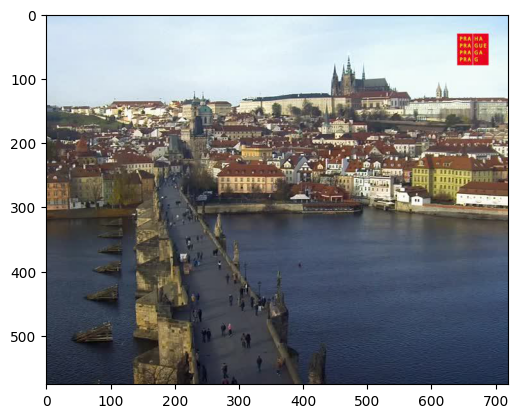

In [7]:
import matplotlib.pyplot as plt

plt.imshow(image)

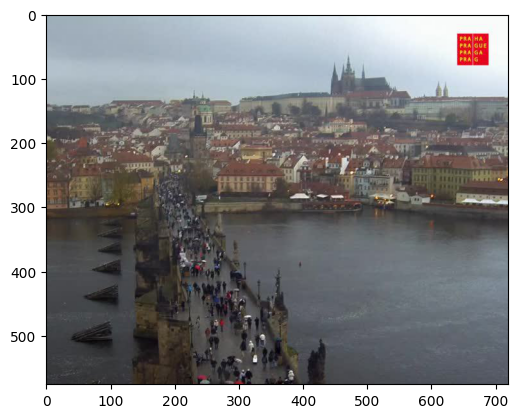

In [8]:
image_crowded = Image.open(r"C:\\Users\\teodorb\\OneDrive - AMDOCS\\Documents\\School\\diplomka\\camera_images\\charles_bride\\camera_101200_20251117_160530.jpg")

plt.imshow(image_crowded)

In [10]:
prompt = "<image> answer cz jaké je počasí?"
prompt_complicated = "<image> Describe the image in detail, focusing on aspects such as weather conditions, crowd density, and notable features. Additionally, provide a crowd density rating on a scale from 0 to 10, where 0 indicates an empty area and 10 signifies extreme overcrowding."
image = Image.open(r"C:\\Users\\teodorb\\OneDrive - AMDOCS\\Documents\\School\\diplomka\\camera_images\\charles_bride\\camera_101200_20251118_095213.jpg")
model_inputs = processor(text=prompt, images=image_crowded, return_tensors="pt").to(torch.bfloat16).to(model.device)
input_len = model_inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**model_inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]
    decoded = processor.decode(generation, skip_special_tokens=True)
    print(decoded)

Zatažené a deštivé


In [23]:
prompt = "<image> answer kolik lidí je na mostě? prosím odpověz mi větou a řekni jak moc si jsi jistý"
prompt_complicated = "<image> answer en Describe the weather on the image and estimate the number of people on the bridge."
image = Image.open(r"C:\\Users\\teodorb\\OneDrive - AMDOCS\\Documents\\School\\diplomka\\camera_images\\charles_bride\\camera_101200_20251118_095213.jpg")
model_inputs = processor(text=prompt_complicated, images=image, return_tensors="pt").to(torch.bfloat16).to(model.device)
input_len = model_inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**model_inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]
    decoded = processor.decode(generation, skip_special_tokens=True)
    print(decoded)

clear, 100 people
